Library code lives in `helper_scripts/lc_*`; this notebook runs workflow + plots only.

# Extrapolate LCs at early times
See Section 2.1.2 in the paper.

We model the early phase of a SN using models described in Equation (2) and (3) in the paper.

In [1]:
import pipeline_config as pconf
from pipeline_config import bootstrap_runtime

rt = pconf.bootstrap_runtime(photometry_stage="dust_corrected", output_stage="extrapolated")
OUTPUT_DIR = rt.output_dir
OUTPUT_PATH = rt.output_path
DATALC_PATH = rt.datalc_path
DATASPEC_PATH = rt.dataspec_path
DATAINFO_PATH = rt.datainfo_path
FILTER_PATH = rt.filter_path
FILTER_LEAF = rt.filter_leaf
FILTERS_PARENT = rt.filters_parent
color_dict, mark_dict, exclude_filt = rt.color_dict, rt.mark_dict, rt.exclude_filt
early_bazin_keep_default = rt.early_bazin_keep
FINAL_SPECTRA_DIR = rt.final_spectra_dir
GP_MODE = rt.gp_mode
import what_the_flux as wtf

import warnings


In [2]:
# exclude_filt comes from bootstrap_runtime / filter_plot_config.json
# Optional per-run override: exclude_filt = exclude_filt + ['SomeBand']


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import emcee
import scipy.optimize as opt

import george
from george.kernels import ExpSquaredKernel, ConstantKernel, Matern32Kernel

%matplotlib inline
#from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))


In [3]:
# Early Bazin helpers (library code in helper_scripts/lc_*)
from lc_bazin_fit_config import BazinFitConfig, default_bazin_fit_config, load_sn_type_lists
from lc_bazin_fit import perform_bazin_fit
from lc_bazin_models import bazin_forced_zero_factory
from lc_rising_photometry import EarlyLCPhotometry
from lc_extrap_helpers import (
    clip_extrap_uncertainties,
    covariance_is_bad,
    decode_band,
    pick_reference_band,
    filters_within_explosion_window,
    early_bands_stage_a,
    validate_bands_keep,
    normalize_bands_keep,
    phase_reference_mjd,
    bazin_forced_zero_t0_bounds_guess,
)

snname = 'AT2017gfo'
se_sne, hydr_sne = load_sn_type_lists(DATAINFO_PATH)
bazin_config = default_bazin_fit_config(snname, se_sne=se_sne, hydr_sne=hydr_sne)
# optional per-run overrides:
# bazin_config.pre_bump["AT2017gfo"] = ...

explosion_dates = bazin_config.explosion_dates
pre_bump = bazin_config.pre_bump
include_dict = bazin_config.include_dict
performe_fit = perform_bazin_fit



### Load Photometry and clip it

In [4]:
SN = EarlyLCPhotometry(lc_path=DATALC_PATH, snname=snname, exclude_filt=exclude_filt, verbose=True, dataspec_path=DATASPEC_PATH)
SN.load()
SN.get_availfilter()
SN.clip_photometry(pre_bump=snname in bazin_config.pre_bump)


Looking for Photometry for AT2017gfo in/Users/ravkaur/Desktop/research/kilonova-SED/kn-sed-pipeline/Inputs/Photometry/2_LCs_dust_corrected/AT2017gfo.dat
Got it!
Photometry loaded
ANDICAM_K Before clipping 4, after 4
DECam_Y Before clipping 10, after 10
DECam_g Before clipping 7, after 7
DECam_i Before clipping 10, after 10
DECam_r Before clipping 8, after 8
DECam_u Before clipping 3, after 3
DECam_z Before clipping 10, after 10
EFOSC2_U Before clipping 1, after 1
FLAMINGOS-2_H Before clipping 10, after 10
FLAMINGOS-2_J Before clipping 5, after 5
FLAMINGOS-2_Ks Before clipping 7, after 7
FORS2_B Before clipping 2, after 2
FORS2_I Before clipping 5, after 5
FORS2_R Before clipping 4, after 4
FORS2_V Before clipping 4, after 4
FourStar_H Before clipping 3, after 3
FourStar_J Before clipping 4, after 4
FourStar_J1 Before clipping 2, after 2
FourStar_Ks Before clipping 8, after 8
GFC_i Before clipping 3, after 3
GFC_r Before clipping 1, after 1
GFC_y Before clipping 5, after 5
GFC_z Before 

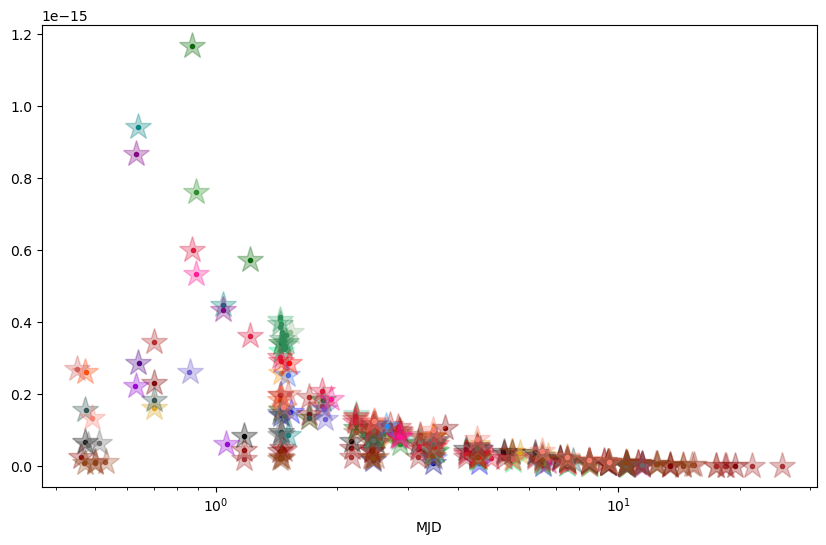

In [5]:
plt.figure(figsize=(10,6))
for filt in SN.avail_filters:
    mask_raw = SN.phot['band'] == filt
    mask_clipped = SN.clipped_phot['band'] == filt
    plt.plot(SN.phot['MJD'][mask_raw] - 57982.52851852, SN.phot['Flux'][mask_raw], 
             '.', label=f'{filt.decode() if isinstance(filt, bytes) else filt} raw', 
             color=color_dict.get(filt.decode() if isinstance(filt, bytes) else filt, None), alpha=0.9)
    plt.plot(SN.clipped_phot['MJD'][mask_clipped] - 57982.52851852, SN.clipped_phot['Flux'][mask_clipped], 
             '*', markersize=20, label=f'{filt.decode() if isinstance(filt, bytes) else filt} clipped', 
             color=color_dict.get(filt.decode() if isinstance(filt, bytes) else filt, None), alpha=0.3)

plt.xlabel('MJD')
plt.xscale('log')
#plt.legend()
plt.show()


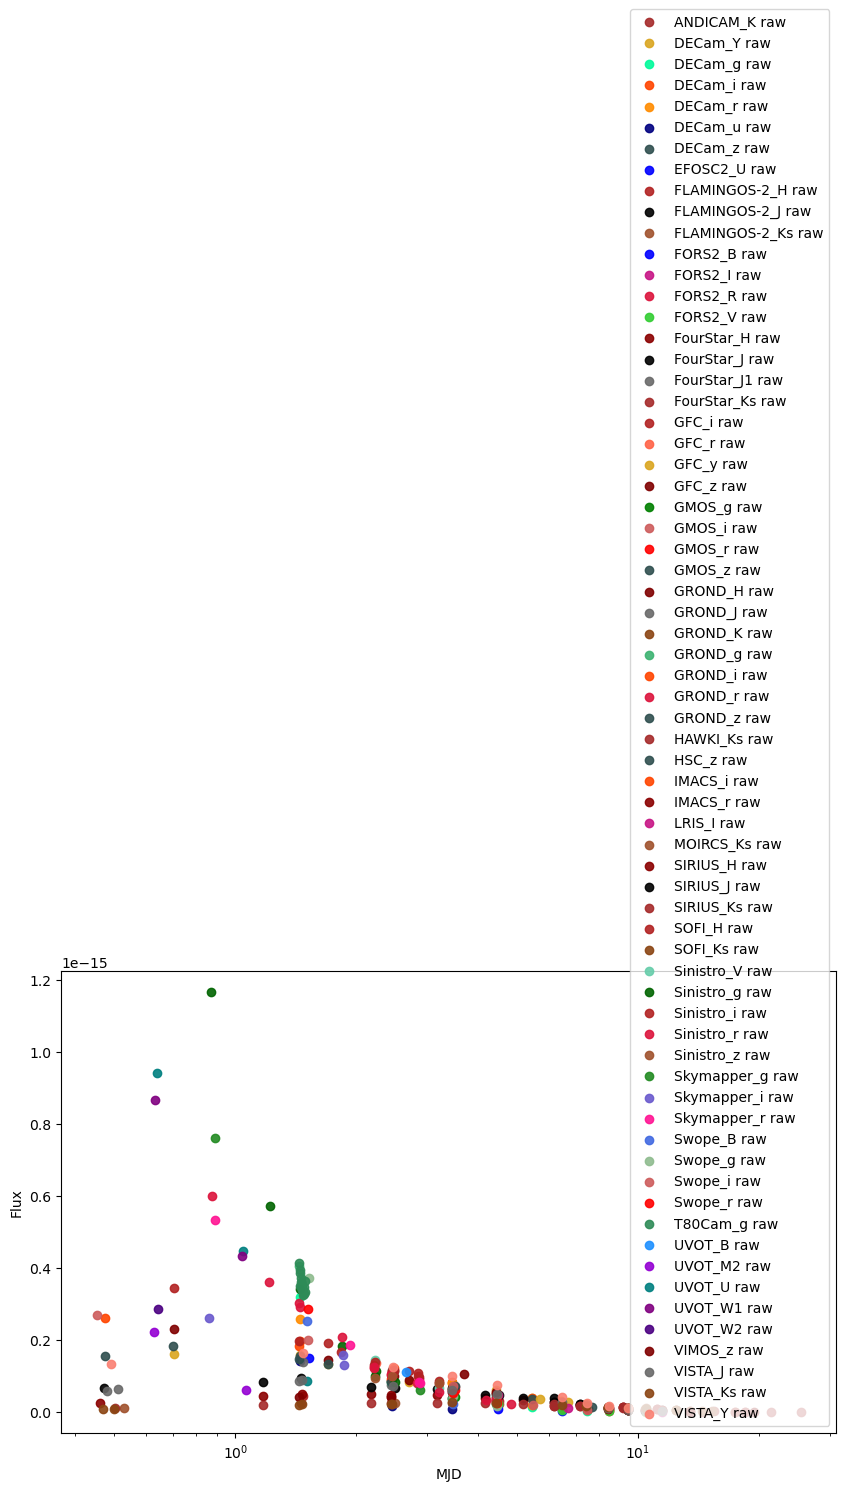

In [6]:
#plt.plot(SN.phot['MJD'], SN.phot['Flux'], '.')
#plt.plot(SN.clipped_phot['MJD'], SN.clipped_phot['Flux'], '.')
plt.figure(figsize=(10,6))
for filt in SN.avail_filters:
    mask_raw = SN.phot['band'] == filt
    mask_clipped = SN.clipped_phot['band'] == filt
    plt.scatter(SN.phot['MJD'][mask_raw] - 57982.52851852, SN.phot['Flux'][mask_raw], 
              label=f'{filt.decode() if isinstance(filt, bytes) else filt} raw', 
             color=color_dict.get(filt.decode() if isinstance(filt, bytes) else filt, None), alpha=0.9)
    #plt.plot(SN.clipped_phot['MJD'][mask_clipped], SN.clipped_phot['Flux'][mask_clipped], 
             #'*', markersize=20, label=f'{filt.decode() if isinstance(filt, bytes) else filt} clipped', 
             #color=color_dict.get(filt.decode() if isinstance(filt, bytes) else filt, None), alpha=0.3)

plt.xlabel('MJD')
plt.ylabel('Flux')
plt.legend(loc='lower right')
plt.xscale('log')
plt.show()


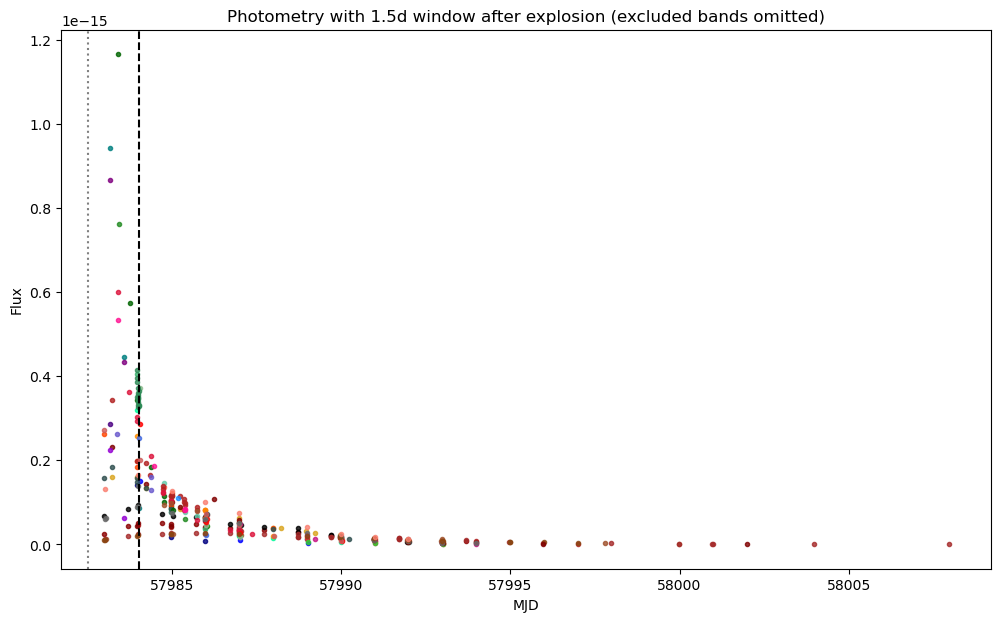

Filters with data within 1.5 days after explosion date:
['DECam_Y', 'DECam_g', 'DECam_i', 'DECam_r', 'DECam_u', 'DECam_z', 'FLAMINGOS-2_H', 'FLAMINGOS-2_Ks', 'FourStar_H', 'FourStar_J', 'FourStar_J1', 'FourStar_Ks', 'GFC_i', 'GFC_y', 'GFC_z', 'GROND_H', 'GROND_J', 'GROND_K', 'GROND_g', 'GROND_i', 'GROND_r', 'GROND_z', 'HSC_z', 'SIRIUS_H', 'SIRIUS_J', 'SIRIUS_Ks', 'Sinistro_g', 'Sinistro_i', 'Sinistro_r', 'Skymapper_g', 'Skymapper_i', 'Skymapper_r', 'Swope_i', 'T80Cam_g', 'UVOT_M2', 'UVOT_U', 'UVOT_W1', 'UVOT_W2', 'VISTA_J', 'VISTA_Ks', 'VISTA_Y']
Filters with data OUTSIDE window (excluding config exclude list):
['ANDICAM_K', 'EFOSC2_U', 'FLAMINGOS-2_J', 'FORS2_B', 'FORS2_I', 'FORS2_R', 'FORS2_V', 'GFC_r', 'GMOS_g', 'GMOS_i', 'GMOS_r', 'GMOS_z', 'HAWKI_Ks', 'IMACS_i', 'IMACS_r', 'LRIS_I', 'MOIRCS_Ks', 'SOFI_H', 'SOFI_Ks', 'Sinistro_V', 'Sinistro_z', 'Swope_B', 'Swope_g', 'Swope_r', 'UVOT_B', 'VIMOS_z']


In [7]:
explosion_date = pconf.explosion_date_mjd(snname)
EARLY_DATA_WINDOW_D = 1.5  # Bazin Stage A: need data within this many days of explosion
window = EARLY_DATA_WINDOW_D
_exclude = set(exclude_filt)

plt.figure(figsize=(12, 7))
filters_within_window, filters_outside_window = filters_within_explosion_window(
    SN.phot, explosion_date, window, _exclude
)

for filt in SN.avail_filters:
    b = decode_band(filt)
    if b in _exclude:
        continue
    mask = SN.phot['band'] == filt
    mjds = SN.phot['MJD'][mask]
    fluxes = SN.phot['Flux'][mask]
    plt.plot(
        mjds, fluxes, '.',
        label=b,
        color=color_dict.get(b, None), alpha=0.8,
    )

plt.axvline(explosion_date + window, color='k', linestyle='--', label=f'Explosion + {window}d')
plt.axvline(explosion_date, color='gray', linestyle=':', label='Explosion date')
plt.xlabel('MJD')
plt.ylabel('Flux')
plt.title(f'Photometry with {window}d window after explosion (excluded bands omitted)')
plt.show()

print(f"Filters with data within {window} days after explosion date:")
print(filters_within_window)
print("Filters with data OUTSIDE window (excluding config exclude list):")
print(filters_outside_window)


## Early Bazin: preview → pick → commit

| Stage | Cell | Writes pipeline? |
|---|---|---|
| **Preview** | Next cell | No — inspect subplot grid; fills `fits_cache_preview` |
| **Pick** | Following cell | No — edit `early_bands_keep` |
| **Commit** | After pick | Yes — appends extrap points and saves `3_LCs_extrapolated/` |

`exclude_filt` from `filter_plot_config.json` is applied at load and in Stage-A candidates.
Reference band is optional (first available from `REFERENCE_BAND_CANDIDATES` not excluded).


Preview candidates (Stage A): ['DECam_Y', 'DECam_g', 'DECam_i', 'DECam_r', 'DECam_u', 'DECam_z', 'FLAMINGOS-2_H', 'FLAMINGOS-2_Ks', 'FourStar_H', 'FourStar_J', 'FourStar_J1', 'FourStar_Ks', 'GFC_i', 'GFC_y', 'GFC_z', 'GROND_H', 'GROND_J', 'GROND_K', 'GROND_g', 'GROND_i', 'GROND_r', 'GROND_z', 'HSC_z', 'SIRIUS_H', 'SIRIUS_J', 'SIRIUS_Ks', 'Sinistro_g', 'Sinistro_i', 'Sinistro_r', 'Skymapper_g', 'Skymapper_i', 'Skymapper_r', 'Swope_i', 'T80Cam_g', 'UVOT_M2', 'UVOT_U', 'UVOT_W1', 'UVOT_W2', 'VISTA_J', 'VISTA_Ks', 'VISTA_Y']
Reference band Sinistro_V: first data 0.00 d from peak
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57984.75, 30.0, 5.0]
#######################COVARIANCE MATRIX unstable (high condition number or invalid diag)


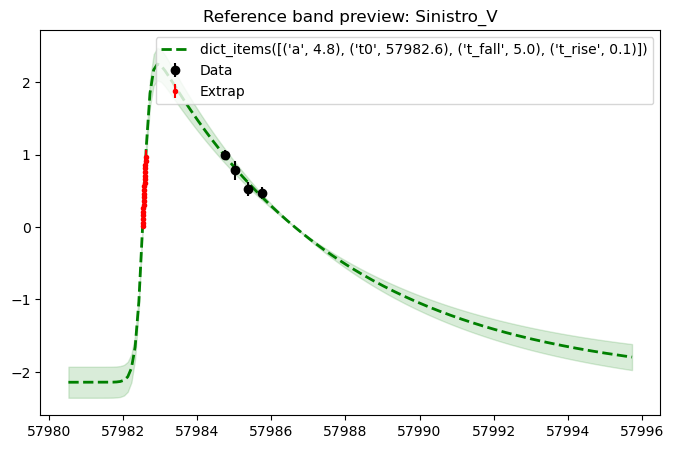

Preview — Bazin on all candidates (no CSV write):

DECam_Y first data: 0.00 d from peak
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.98, 30.0, 5.0]
DECam_g first data: 0.00 d from peak
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.98, 30.0, 5.0]
DECam_i first data: 0.00 d from peak
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.0, 30.0, 5.0]
DECam_r first data: 0.00 d from peak
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.98, 30.0, 5.0]
DECam_u first data: 0.00 d from peak
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.98, 30.0, 5.0]
#######################COVARIANCE MATRIX unstable (high condition number or invalid diag)
DECam_z first data: 0.00 d from peak
Fitting Forced-Zero Bazin ['a', 't0', 't_fall', 't_rise'] Initial guess [1.0, 57983.0, 30.0, 5.0]
FLAMINGOS-2_H first data: 0.00 d from peak
Fi

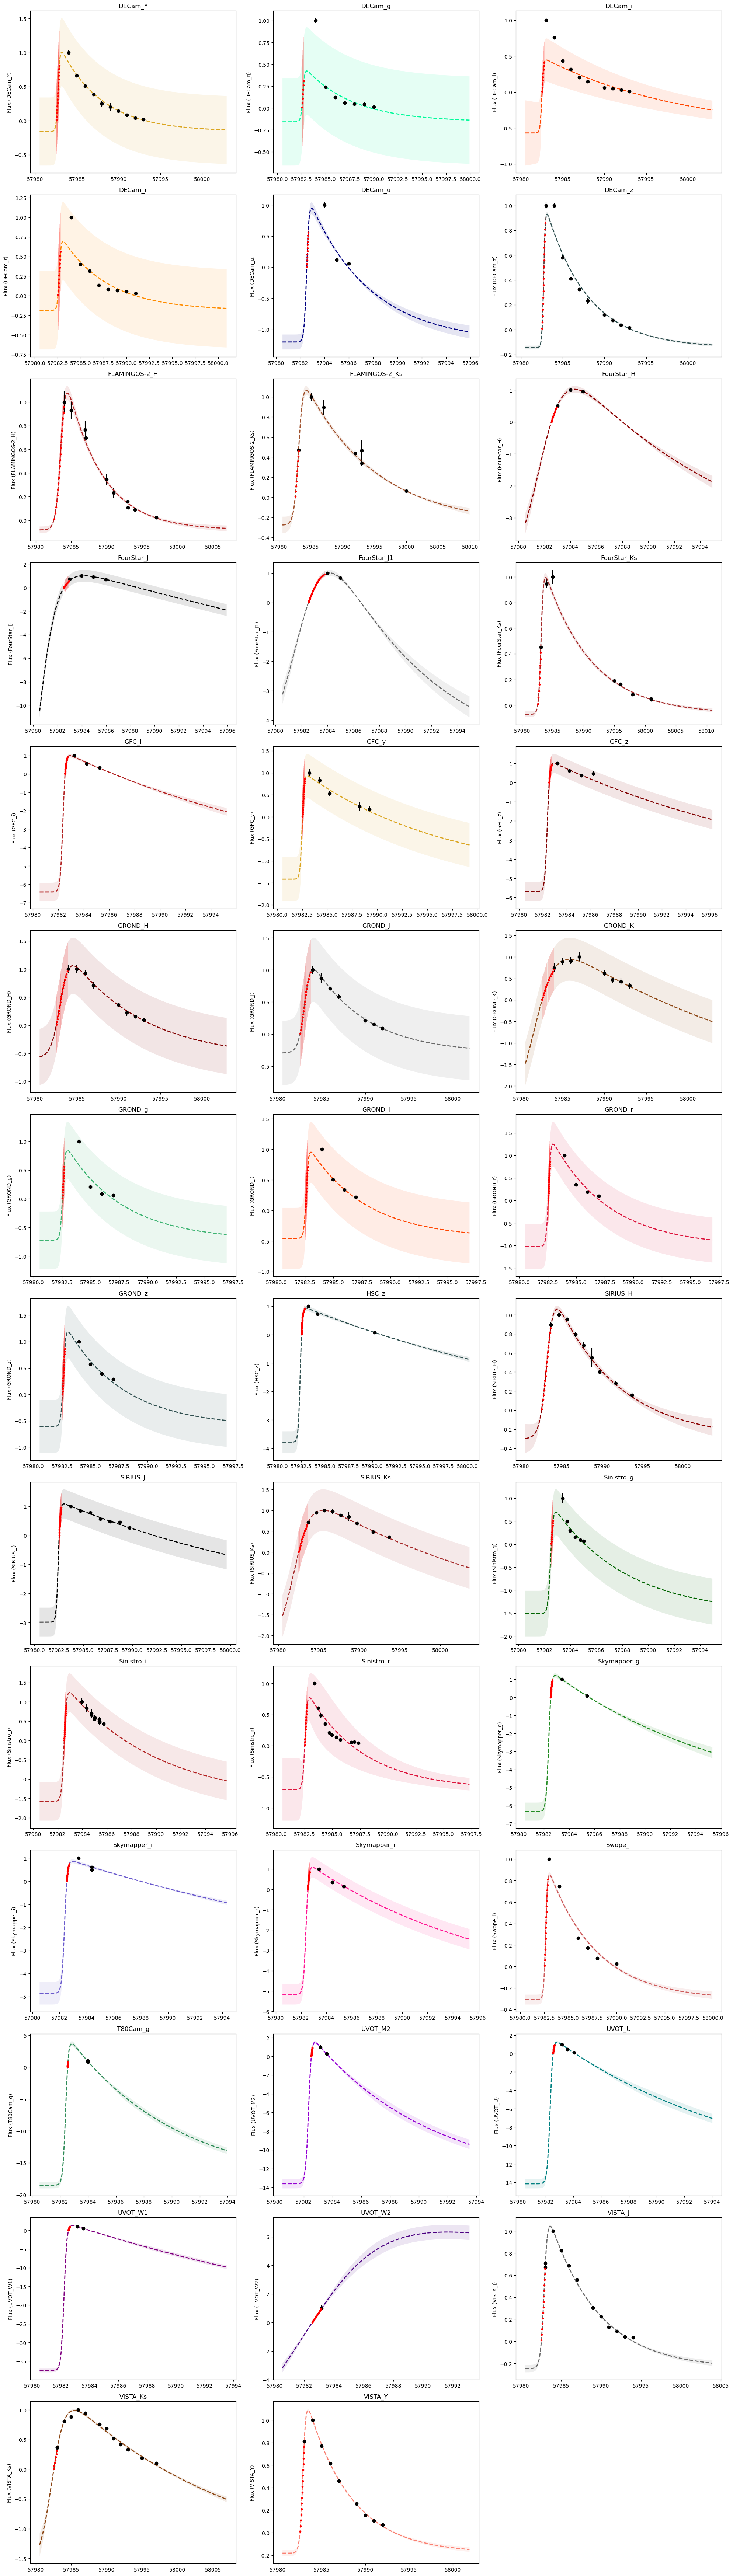

Preview cache keys: ['DECam_Y', 'DECam_g', 'DECam_i', 'DECam_r', 'DECam_u', 'DECam_z', 'FLAMINGOS-2_H', 'FLAMINGOS-2_Ks', 'FourStar_H', 'FourStar_J', 'FourStar_J1', 'FourStar_Ks', 'GFC_i', 'GFC_y', 'GFC_z', 'GROND_H', 'GROND_J', 'GROND_K', 'GROND_g', 'GROND_i', 'GROND_r', 'GROND_z', 'HSC_z', 'SIRIUS_H', 'SIRIUS_J', 'SIRIUS_Ks', 'Sinistro_V', 'Sinistro_g', 'Sinistro_i', 'Sinistro_r', 'Skymapper_g', 'Skymapper_i', 'Skymapper_r', 'Swope_i', 'T80Cam_g', 'UVOT_M2', 'UVOT_U', 'UVOT_W1', 'UVOT_W2', 'VISTA_J', 'VISTA_Ks', 'VISTA_Y']


In [8]:
COMMIT_REUSE_PREVIEW = True  # reuse successful preview fits on commit

fits_cache_preview = {}
ref_fit_cache = None

_exclude = set(exclude_filt)
band_init = pick_reference_band(SN.avail_filters, _exclude, pconf.REFERENCE_BAND_CANDIDATES)
explosion_mjd = pconf.explosion_date_mjd(snname)
mjd_phase_ref = explosion_mjd

include_bands = include_dict.get(snname, [])
early_bands_candidates = early_bands_stage_a(
    filters_within_window,
    _exclude,
    include_bands,
    band_init,
    se_sne,
    snname,
)
print("Preview candidates (Stage A):", early_bands_candidates)

if band_init is not None:
    flux_V = SN.clipped_phot[SN.clipped_phot['band'] == band_init]['Flux']
    fluxerr_V = SN.clipped_phot[SN.clipped_phot['band'] == band_init]['Flux_err']
    t_V = SN.clipped_phot[SN.clipped_phot['band'] == band_init]['MJD']
    if len(flux_V) == 0:
        print(f"Reference band {band_init!r} has no clipped data; skipping reference fit.")
        band_init = None
    else:
        mjd_ref_peak = t_V[np.argmax(flux_V)]
        ref_peak = max(flux_V)
        if snname in pre_bump.keys():
            mjd_ref_peak = explosion_dates[snname][0] + pre_bump[snname][0]
            ref_peak = max(flux_V[t_V > min(t_V) + pre_bump[snname][0]])
        mjd_phase_ref = mjd_ref_peak
        t_ = np.array(t_V)
        phase_ = t_ - mjd_ref_peak
        flux_ = np.array(flux_V) / ref_peak
        fluxerr_ = np.array(fluxerr_V) / ref_peak
        print(f"Reference band {band_init}: first data {min(t_) - mjd_ref_peak:.2f} d from peak")
        success = False
        try:
            R, cov, t_extrapV, fittedV, fittedV_err, t_newpts, newpts_, newpts_err, label_dict, success = (
                perform_bazin_fit(snname, band_init, t_, flux_, fluxerr_, phase_, mjd_phase_ref, config=bazin_config)
            )
        except Exception as exc:
            print(f"  preview skip reference {band_init}: {exc}")
        if success:
            plt.figure(figsize=(8, 5))
            plt.errorbar(t_, flux_, yerr=fluxerr_, fmt='ok', label='Data')
            plt.plot(t_extrapV, fittedV, 'g--', lw=2, label=str(label_dict))
            plt.fill_between(t_extrapV, fittedV - fittedV_err, fittedV + fittedV_err, alpha=0.15, color='g')
            plt.errorbar(t_newpts, newpts_, yerr=newpts_err, fmt='r.', label='Extrap')
            plt.title(f"Reference band preview: {band_init}")
            plt.legend()
            plt.show()
            ref_fit_cache = {
                'reference_band': True,
                'xpeak': float(ref_peak),
                'mjd_xpeak': float(mjd_ref_peak),
                't_extrap': np.asarray(t_extrapV, dtype=float),
                'fitted_norm': np.asarray(fittedV, dtype=float),
                'fitted_err_norm': np.asarray(fittedV_err, dtype=float),
                't_newpts': np.asarray(t_newpts, dtype=float),
                'newpts_norm': np.asarray(newpts_, dtype=float),
                'newpts_err_norm': np.asarray(newpts_err, dtype=float),
                't_data': np.asarray(t_, dtype=float),
                'flux_norm': np.asarray(flux_, dtype=float),
                'fluxerr_norm': np.asarray(fluxerr_, dtype=float),
                'success': True,
            }
            fits_cache_preview[str(band_init)] = ref_fit_cache
else:
    print(f"No reference band available (excluded or missing); using explosion MJD {mjd_phase_ref}")

N_rows = int(len(early_bands_candidates) / 3) + 1
fig = plt.figure(figsize=(20, N_rows * 5))
i = 1
print("Preview — Bazin on all candidates (no CSV write):\n")

for band in early_bands_candidates:
    plt.subplot(N_rows, 3, i)
    flux_x = SN.clipped_phot[SN.clipped_phot['band'] == band]['Flux']
    fluxerr_x = SN.clipped_phot[SN.clipped_phot['band'] == band]['Flux_err']
    t_x = SN.clipped_phot[SN.clipped_phot['band'] == band]['MJD']
    if len(flux_x) == 0:
        print(f"  skip {band}: no data")
        continue
    xpeak = max(flux_x)
    mjd_xpeak = t_x[np.argmax(flux_x)]
    if snname in pre_bump.keys():
        mjd_xpeak = explosion_dates[snname][0] + pre_bump[snname][0]
        xpeak = max(flux_x[t_x > mjd_xpeak])
    t_ = np.array(t_x)
    phase_ = t_ - mjd_xpeak
    flux_ = np.array(flux_x) / xpeak
    fluxerr_ = np.array(fluxerr_x) / xpeak
    print(band, 'first data: %.2f d from peak' % (min(t_) - mjd_xpeak))
    success = False
    try:
        results = perform_bazin_fit(snname, band, t_, flux_, fluxerr_, phase_, mjd_phase_ref, config=bazin_config)
        R, cov, t_extrap, fitted, fitted_err, t_newpts, newpts_, newpts_err, label_dict, success = results
    except Exception as exc:
        print(f"  preview skip {band}: {exc}")
        i += 1
        continue
    plt.errorbar(t_, flux_, yerr=fluxerr_, fmt='ok', label='Data')
    bc = color_dict.get(band, 'gray')
    plt.plot(t_extrap, fitted, '--', color=bc, lw=2)
    plt.fill_between(t_extrap, fitted - fitted_err, fitted + fitted_err, facecolor=bc, alpha=0.1)
    plt.errorbar(t_newpts, newpts_, yerr=newpts_err, fmt='r.', ecolor='r', elinewidth=0.2)
    plt.ylabel(f'Flux ({band})')
    plt.title(band)
    if success:
        fits_cache_preview[str(band)] = {
            'reference_band': False,
            'xpeak': float(xpeak),
            'mjd_xpeak': float(mjd_xpeak),
            't_extrap': np.asarray(t_extrap, dtype=float),
            'fitted_norm': np.asarray(fitted, dtype=float),
            'fitted_err_norm': np.asarray(fitted_err, dtype=float),
            't_newpts': np.asarray(t_newpts, dtype=float),
            'newpts_norm': np.asarray(newpts_, dtype=float),
            'newpts_err_norm': np.asarray(newpts_err, dtype=float),
            't_data': np.asarray(t_, dtype=float),
            'flux_norm': np.asarray(flux_, dtype=float),
            'fluxerr_norm': np.asarray(fluxerr_, dtype=float),
            'success': True,
        }
    i += 1

plt.tight_layout()
plt.show()
plt.close(fig)
print("Preview cache keys:", sorted(fits_cache_preview.keys()))


### Pick bands to keep

Edit `early_bands_keep` after inspecting the preview grid.

In [10]:
# Edit after running preview — bands whose Bazin looks good
if early_bazin_keep_default:
    early_bands_keep = list(early_bazin_keep_default)
else:
    early_bands_keep = list(early_bands_candidates)  # default: all candidates; trim after QA

# Example manual edit:
early_bands_keep = ['FLAMINGOS-2_Ks', 'FourStar_J', 'FourStar_H', 'FourStar_J1', 'GFC_i', 'GROND_H', 'GROND_J', 'SIRIUS_Ks', 'Skymapper_g', 'Skymapper_r', 'Skymapper_r', 'UVOT_M2', 'UVOT_U', 'UVOT_W1', 'VISTA_J', 'VISTA_Ks', 'VISTA_Y']
print("Bands to commit:", early_bands_keep)


Bands to commit: ['FLAMINGOS-2_Ks', 'FourStar_J', 'FourStar_H', 'FourStar_J1', 'GFC_i', 'GROND_H', 'GROND_J', 'SIRIUS_Ks', 'Skymapper_g', 'Skymapper_r', 'Skymapper_r', 'UVOT_M2', 'UVOT_U', 'UVOT_W1', 'VISTA_J', 'VISTA_Ks', 'VISTA_Y']


Commit — writing kept bands only:
 ['FLAMINGOS-2_Ks', 'FourStar_J', 'FourStar_H', 'FourStar_J1', 'GFC_i', 'GROND_H', 'GROND_J', 'SIRIUS_Ks', 'Skymapper_g', 'Skymapper_r', 'UVOT_M2', 'UVOT_U', 'UVOT_W1', 'VISTA_J', 'VISTA_Ks', 'VISTA_Y']


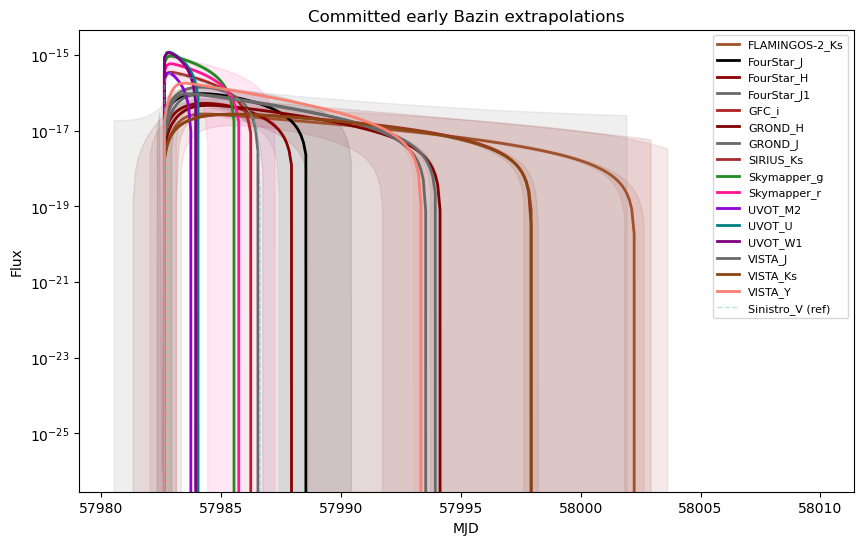

Saved: /Users/ravkaur/Desktop/research/kilonova-SED/kn-sed-pipeline/Inputs/Photometry/3_LCs_extrapolated/AT2017gfo.dat


In [11]:
early_bands_keep = normalize_bands_keep(early_bands_keep)
validate_bands_keep(early_bands_keep, fits_cache_preview.keys())

original_phot = pd.DataFrame(SN.phot.copy())
extr_pts_pd = pd.DataFrame(columns=original_phot.columns)
fits_cache = {}

def _append_extrap_from_cache(band, rec):
    global original_phot
    t_newpts = rec['t_newpts']
    xpeak = rec['xpeak']
    newpts_ = rec['newpts_norm']
    newpts_err = rec['newpts_err_norm']
    row = pd.DataFrame(columns=original_phot.columns)
    row['MJD'] = t_newpts
    row['band'] = np.full(len(t_newpts), fill_value=band)
    row['Flux'] = newpts_ * xpeak
    row['Flux_err'] = newpts_err * xpeak
    row['FilterSet'] = np.full(len(t_newpts), fill_value='SUDO_PTS')
    row['Instr'] = np.full(len(t_newpts), fill_value='SUDO_PTS')
    original_phot = pd.concat([original_phot, row], ignore_index=True)

print("Commit — writing kept bands only:\n", early_bands_keep)

for band in early_bands_keep:
    rec = fits_cache_preview.get(str(band))
    if rec is None or not rec.get('success', False):
        if not COMMIT_REUSE_PREVIEW or rec is None:
            raise ValueError(f"No successful preview fit for {band!r}; re-run preview or drop from keep list")
    _append_extrap_from_cache(band, rec)
    fits_cache[str(band)] = rec

# Summary overlay
fig, ax = plt.subplots(figsize=(10, 6))
for band in early_bands_keep:
    rec = fits_cache[str(band)]
    bc = color_dict.get(band, 'gray')
    fitted = rec['fitted_norm'] * rec['xpeak']
    fitted_err = rec['fitted_err_norm'] * rec['xpeak']
    ax.plot(rec['t_extrap'], fitted, '-', color=bc, lw=2, label=band)
    ax.fill_between(rec['t_extrap'], fitted - fitted_err, fitted + fitted_err, color=bc, alpha=0.1)
if band_init and str(band_init) in fits_cache_preview and str(band_init) not in early_bands_keep:
    rec = fits_cache_preview[str(band_init)]
    bc = color_dict.get(band_init, 'green')
    ax.plot(rec['t_extrap'], rec['fitted_norm'] * rec['xpeak'], '--', color=bc, lw=1, alpha=0.5, label=f"{band_init} (ref)")
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.set_xlabel('MJD')
ax.set_ylabel('Flux')
ax.set_title('Committed early Bazin extrapolations')
plt.show()

t0_fix = bazin_config.explosion_dates[snname][0]
original_phot['Phase'] = original_phot['MJD'] - t0_fix
original_phot = original_phot[original_phot['Phase'] >= 0].copy()
original_phot.loc[original_phot['Phase'] == 0, 'Phase'] = 1e-5
original_phot = original_phot[original_phot['Flux'] >= 0].copy()
original_phot.loc[original_phot['Flux'] == 0, 'Flux'] = 1e-25
original_phot['Log_Phase'] = np.log10(original_phot['Phase'])
original_phot['Log_Flux'] = np.log10(original_phot['Flux'])
original_phot['Log_Flux_err'] = original_phot['Flux_err'] / (original_phot['Flux'] * np.log(10))
original_phot['Flux_err'] = np.where(
    np.isinf(original_phot['Flux_err']) | np.isnan(original_phot['Flux_err']),
    0.1 * np.abs(original_phot['Flux']),
    original_phot['Flux_err'],
)
if 'Log_Flux' in original_phot.columns:
    original_phot['Log_Flux_err'] = original_phot['Flux_err'] / (original_phot['Flux'] * np.log(10))
original_phot.replace([np.inf, -np.inf], np.nan, inplace=True)

original_phot.to_csv(OUTPUT_PATH + '/%s.dat' % snname, na_rep='nan', index=False, sep='\t')
print("Saved:", OUTPUT_PATH + '/%s.dat' % snname)


### Extend fit diagnostics (optional)

Four-panel QA plots for rising Bazin extend per band. Not required for pipeline output.


Bazin params [A, t0, t_fall, t_rise]: [10.41797988 -4.19475892 34.80789603  1.22406587]


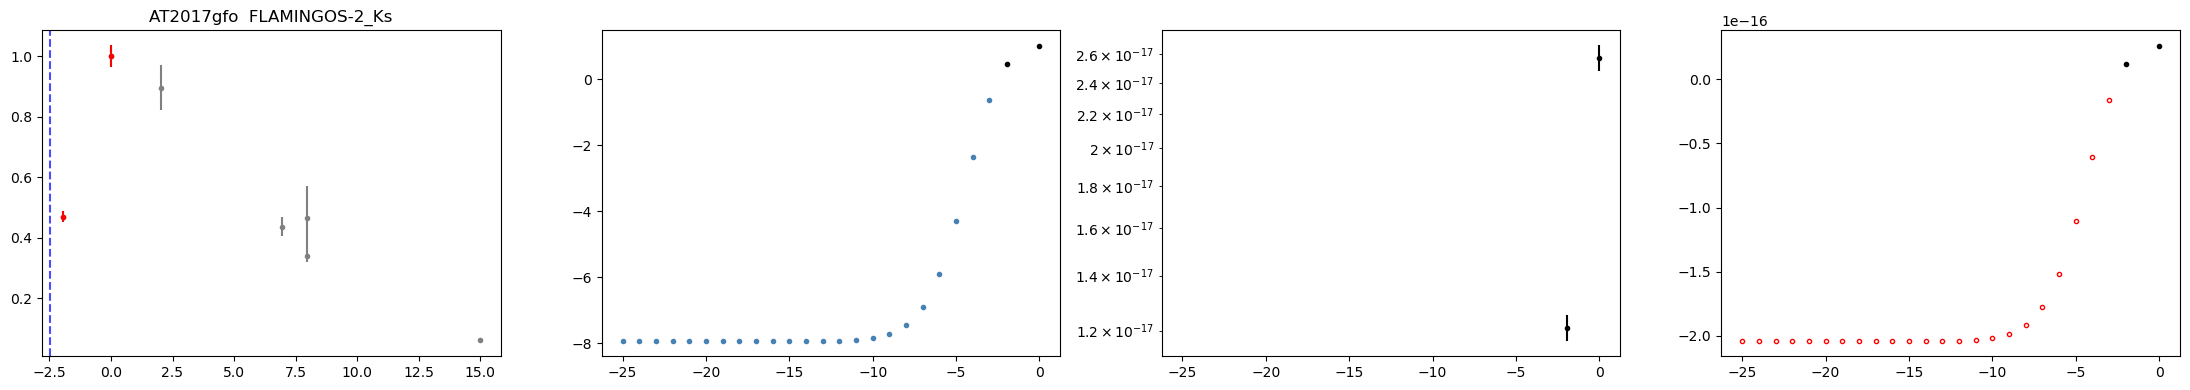

Bazin params [A, t0, t_fall, t_rise]: [14.03501684 -2.58500863 33.5693042   0.59043847]


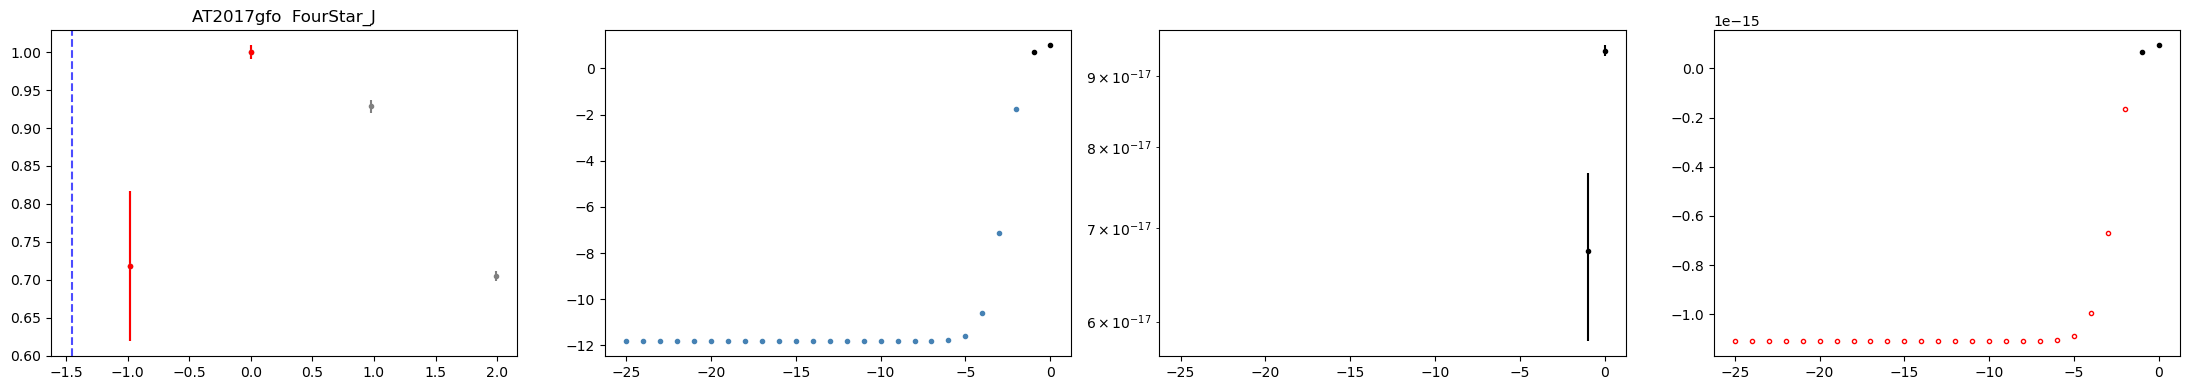

Bazin params [A, t0, t_fall, t_rise]: [14.01018512 -3.24955243 34.23323427  1.10028027]


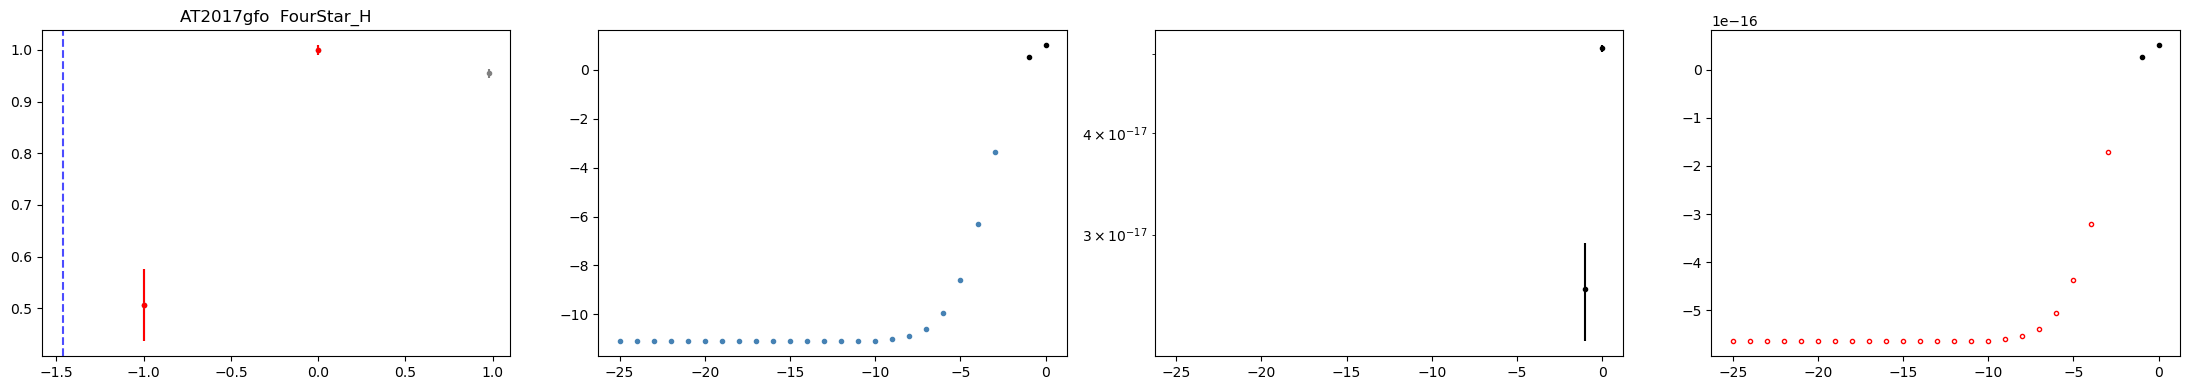

Bazin params [A, t0, t_fall, t_rise]: [14.96782193  4.34227894 36.15434684  2.94202136]


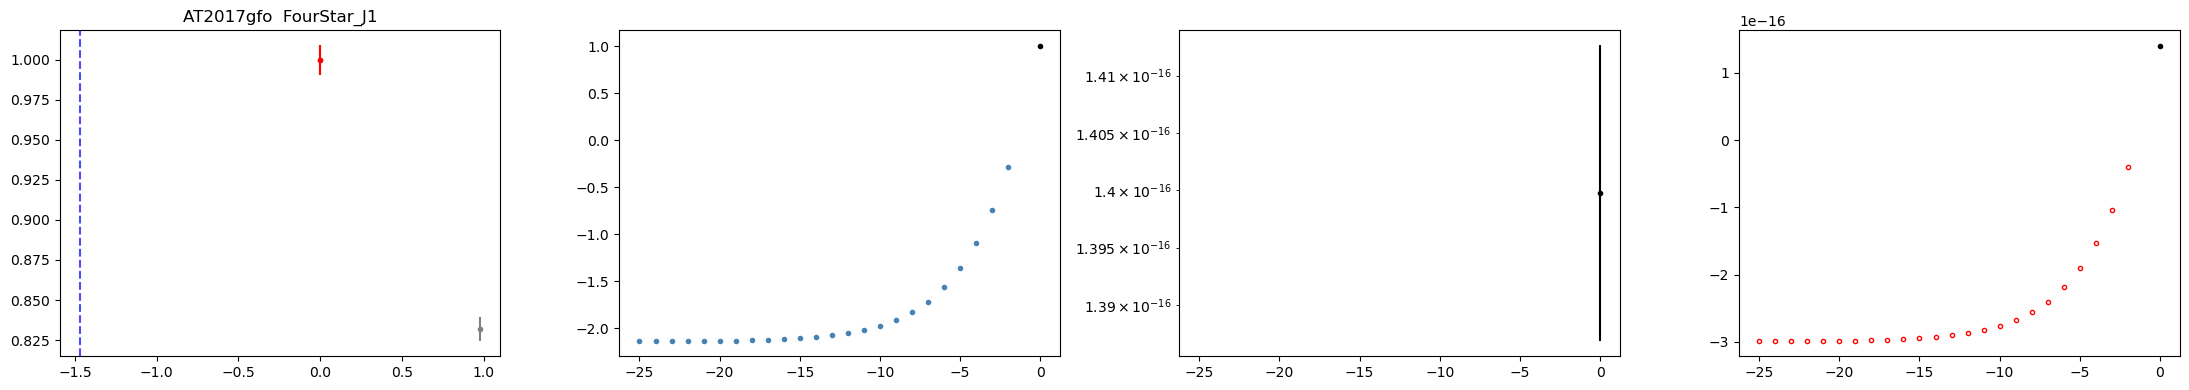

Bazin params [A, t0, t_fall, t_rise]: [10.03938549  1.14094841 46.59404927  1.25207105]


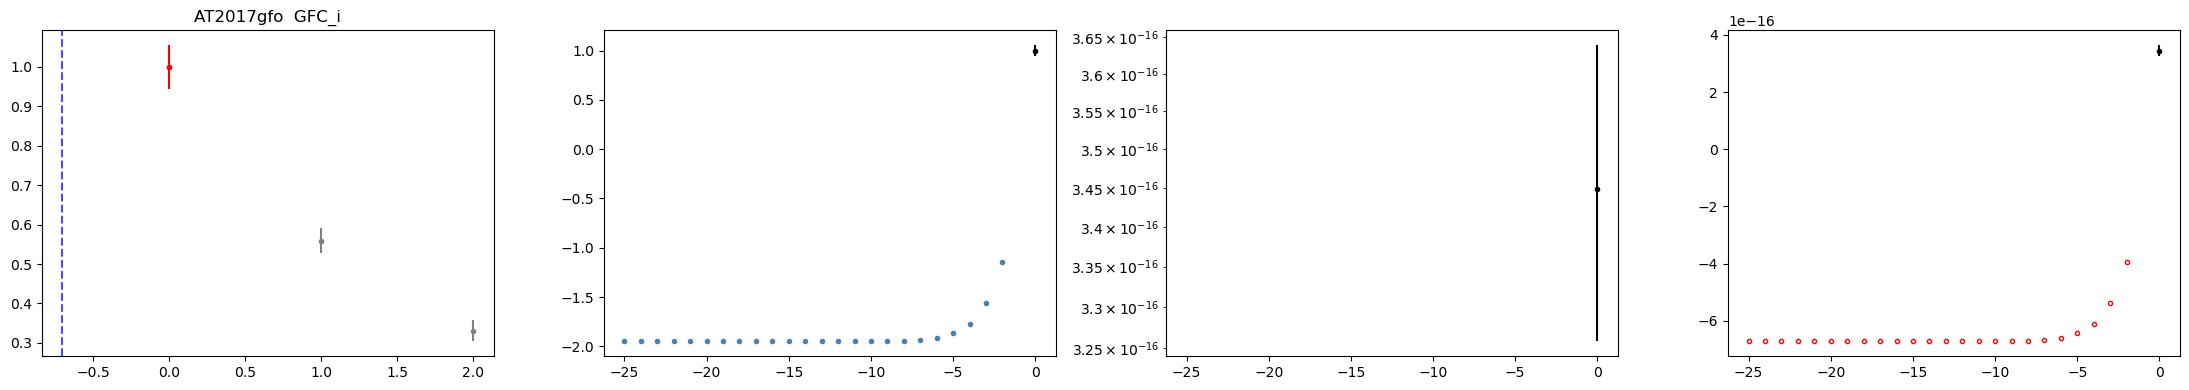

Bazin params [A, t0, t_fall, t_rise]: [14.62814372  4.14878817 33.42122569  2.84544667]


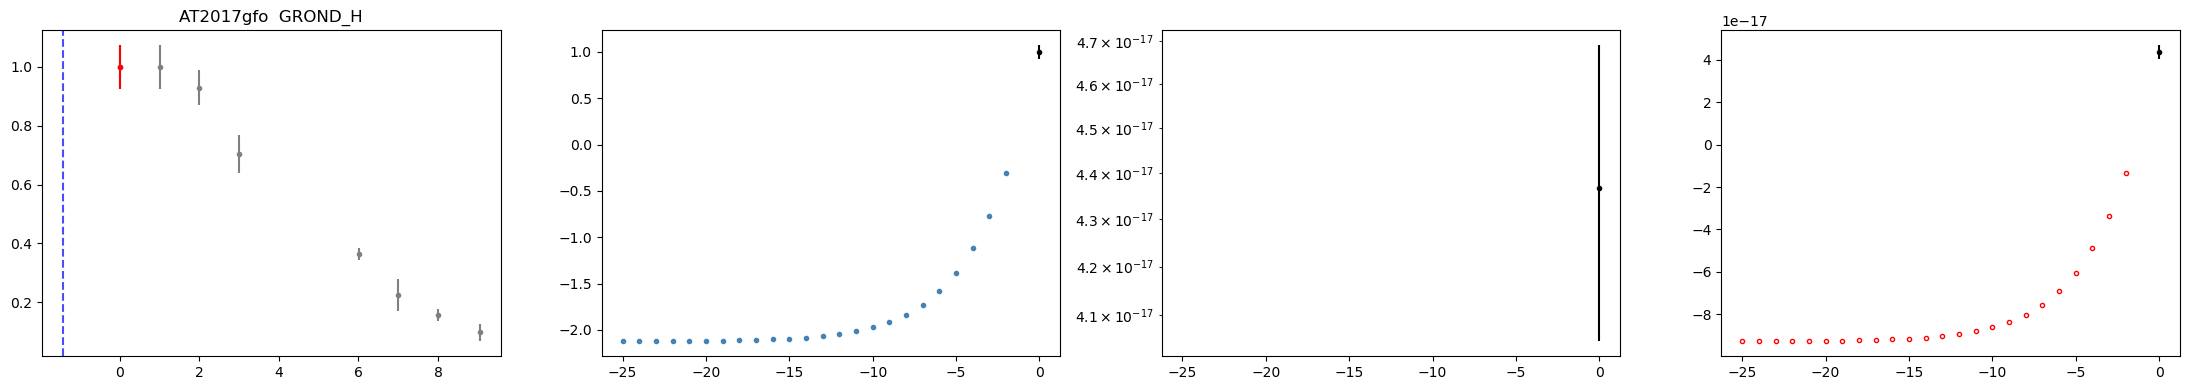

Bazin params [A, t0, t_fall, t_rise]: [14.62814431  4.14878828 33.42125035  2.84544743]


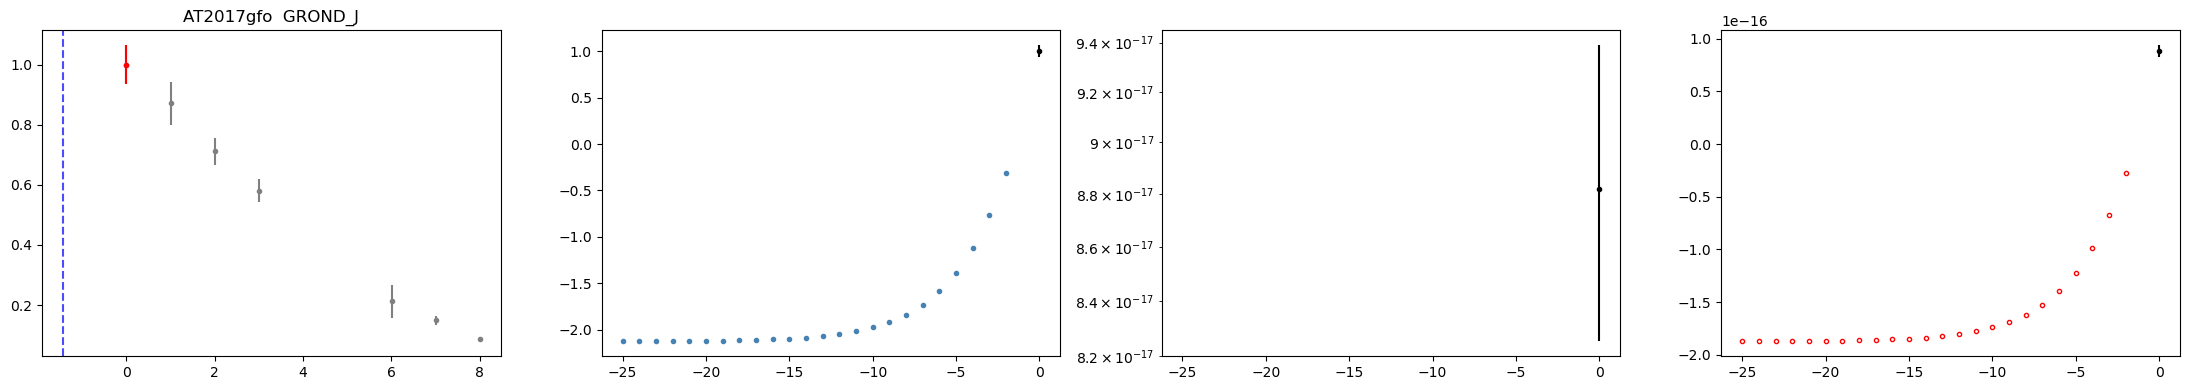

Bazin params [A, t0, t_fall, t_rise]: [ 4.5773935  -4.10812848 71.50303872  0.98934899]


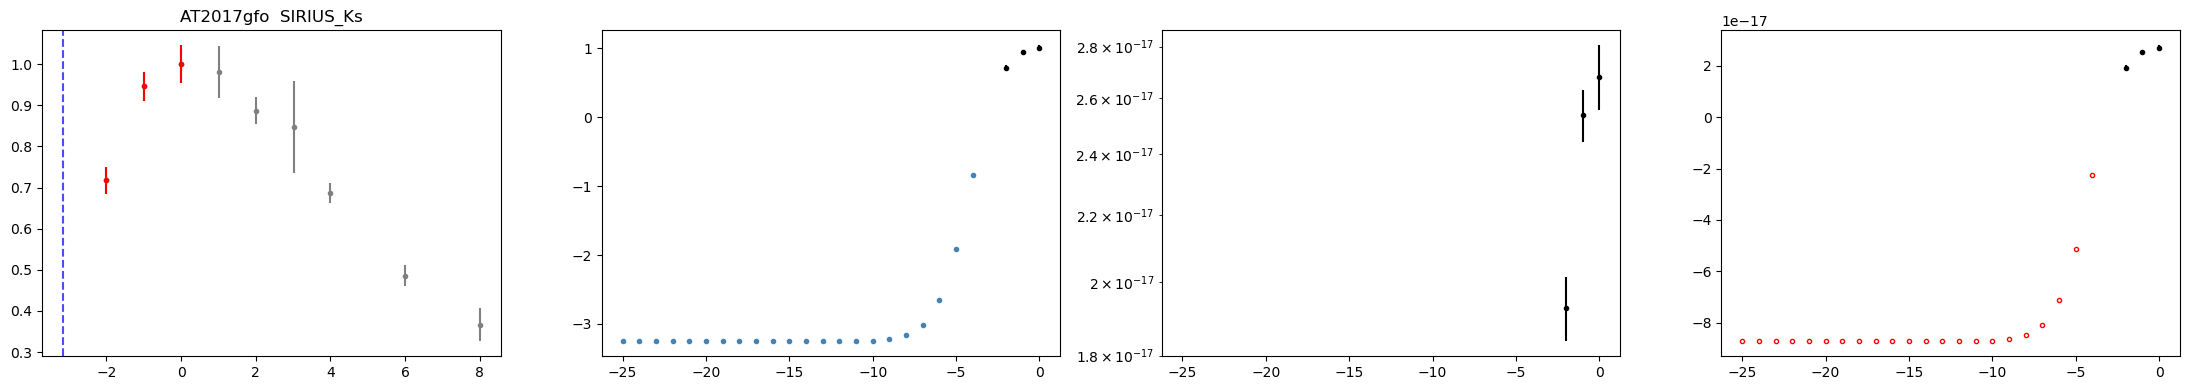

Bazin params [A, t0, t_fall, t_rise]: [ 8.44354125 -1.23080965 36.26274492  1.52163444]


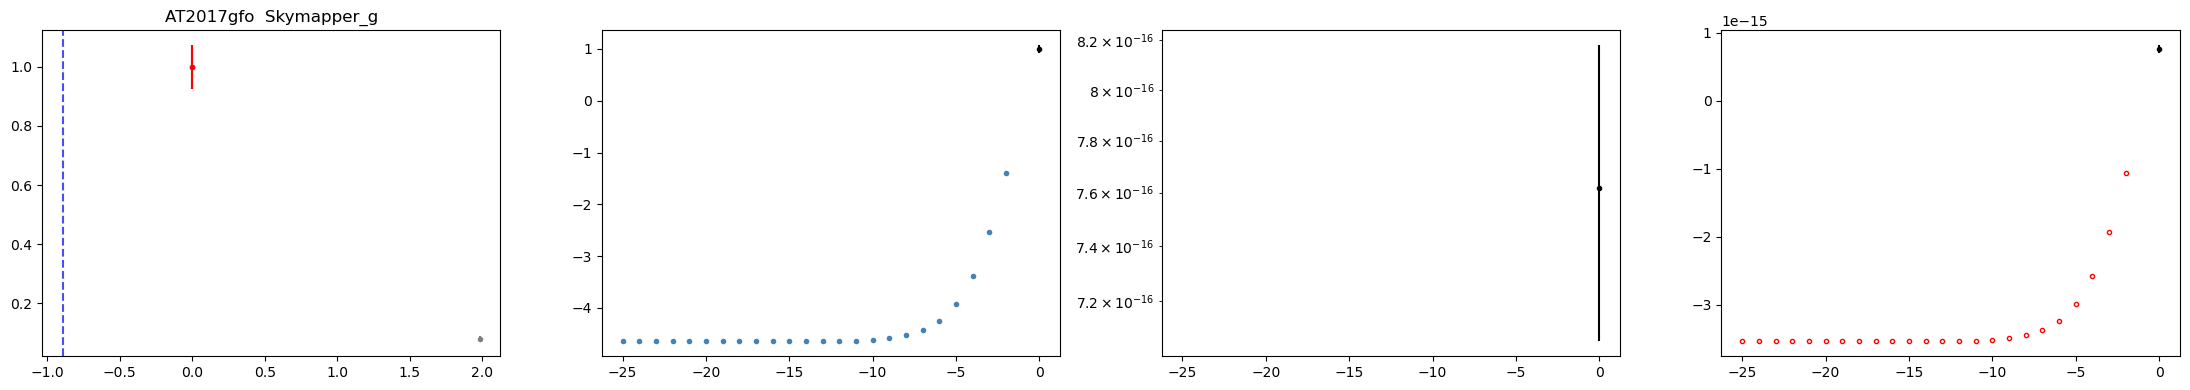

Bazin params [A, t0, t_fall, t_rise]: [ 8.44354325 -1.23081575 36.26274637  1.52163246]


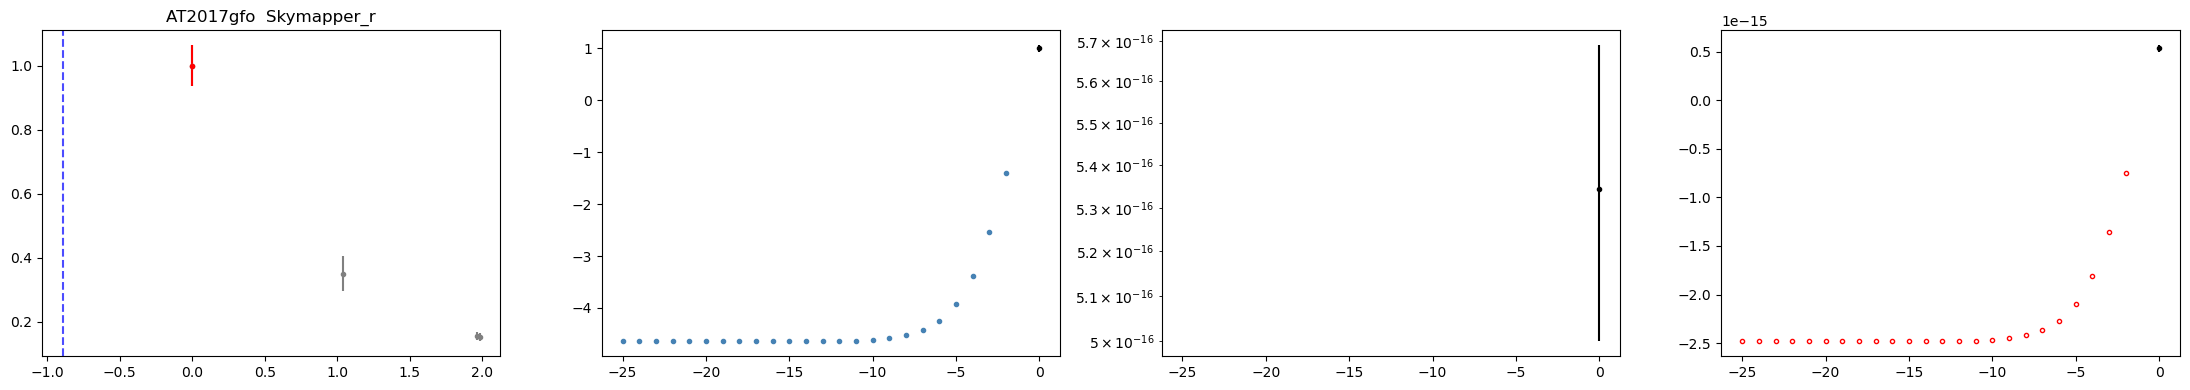

Bazin params [A, t0, t_fall, t_rise]: [10.07891651  0.9577672  35.95772039  1.20001887]


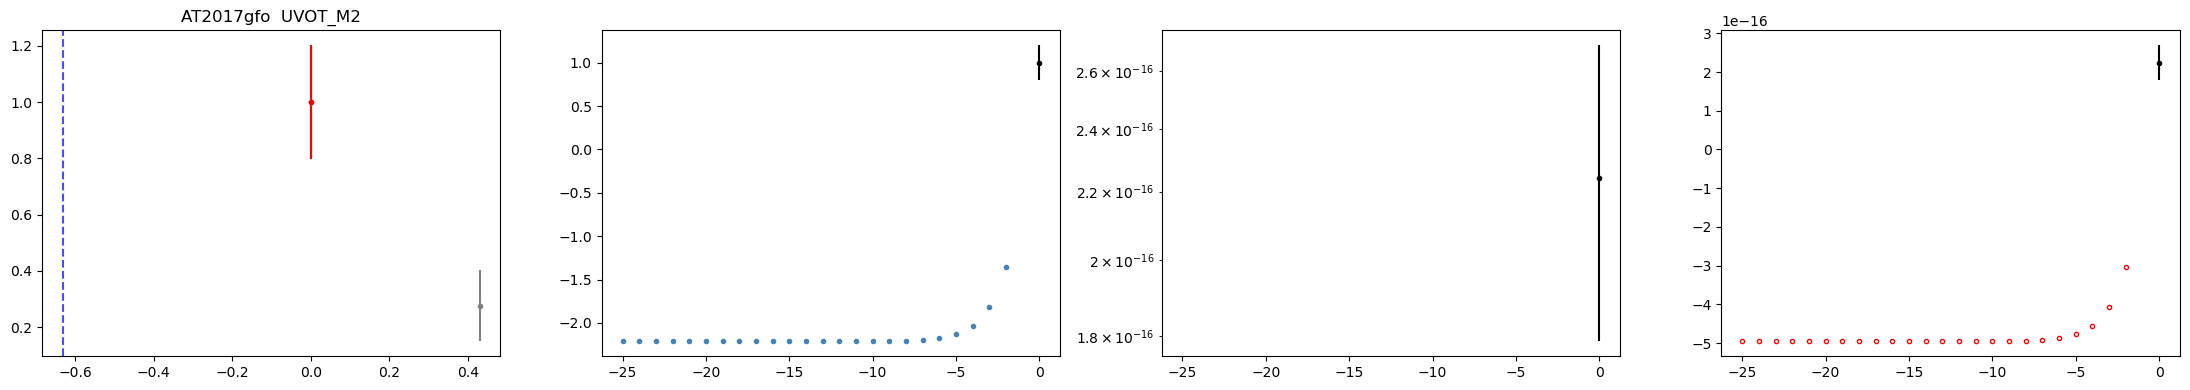

Bazin params [A, t0, t_fall, t_rise]: [ 8.8520698   0.61188208 34.98861583  1.18743458]


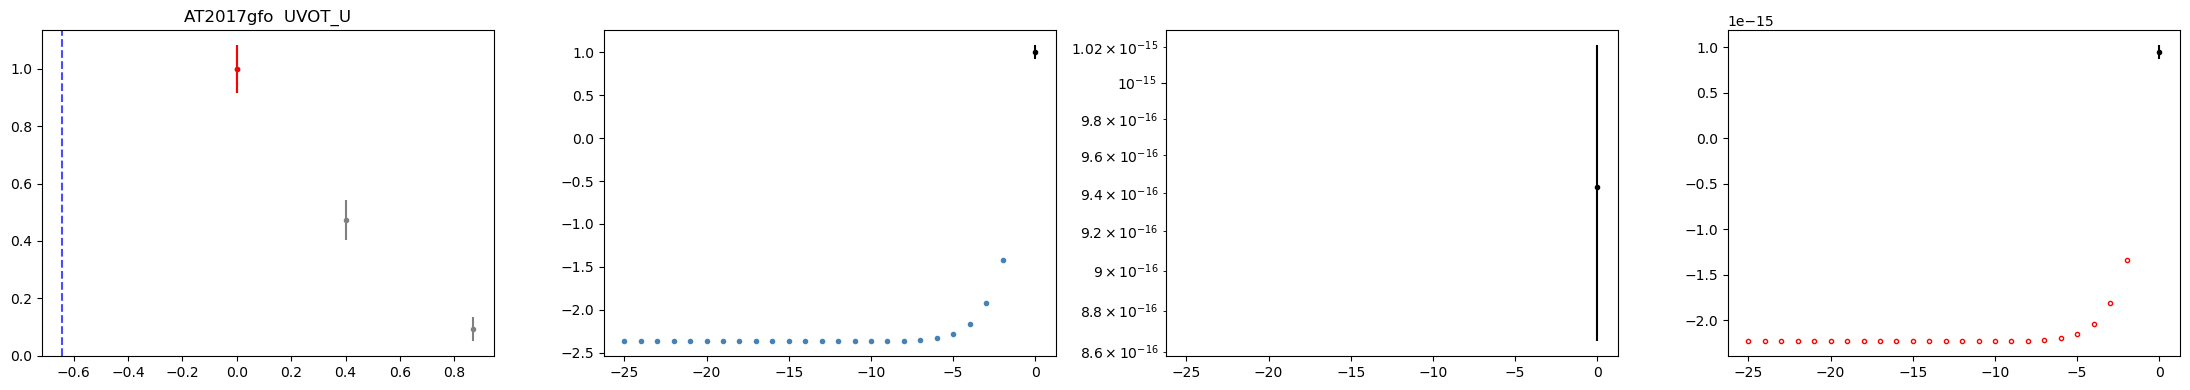

Bazin params [A, t0, t_fall, t_rise]: [10.07890917  0.95775141 35.95735977  1.20002953]


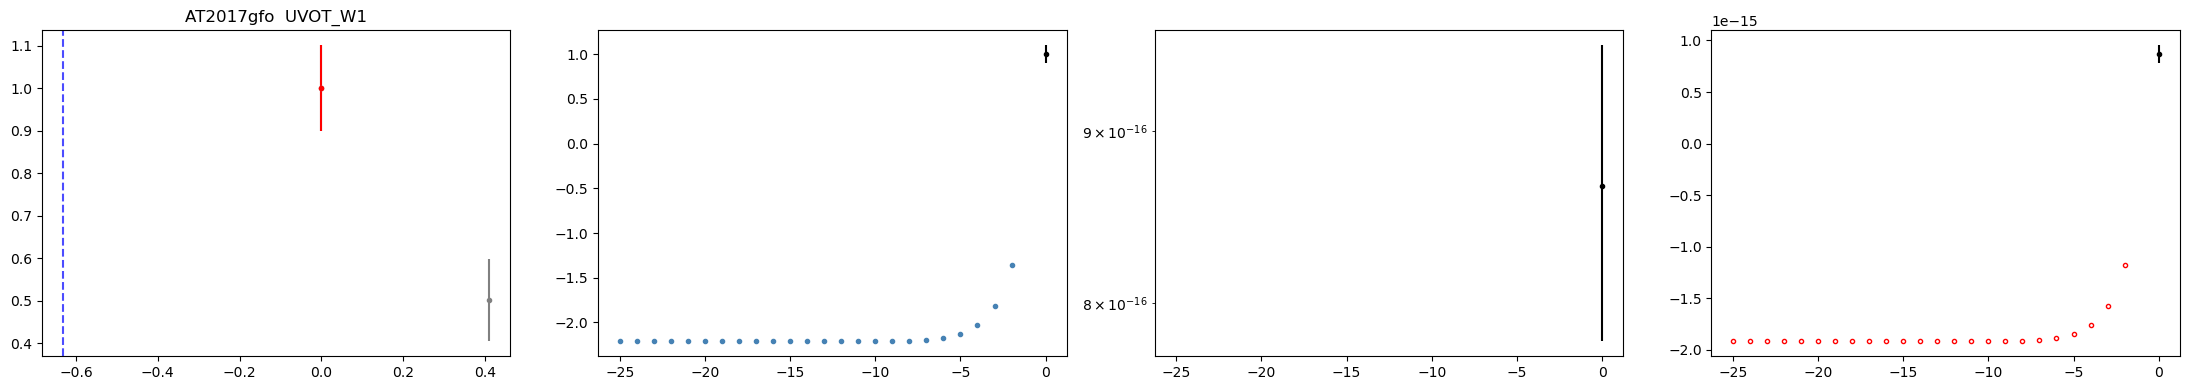

Bazin params [A, t0, t_fall, t_rise]: [147.28209951   1.97472845   5.00000075   3.31640195]


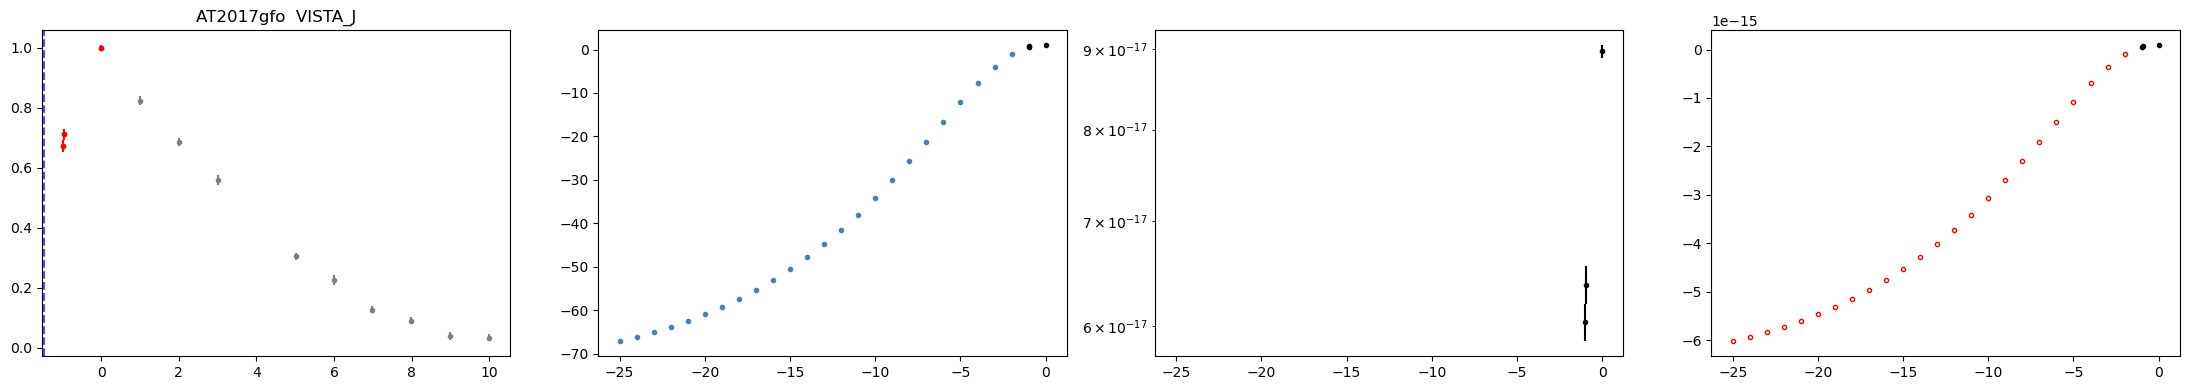

Bazin params [A, t0, t_fall, t_rise]: [  3.39856318  -4.04750455 100.           0.85027746]


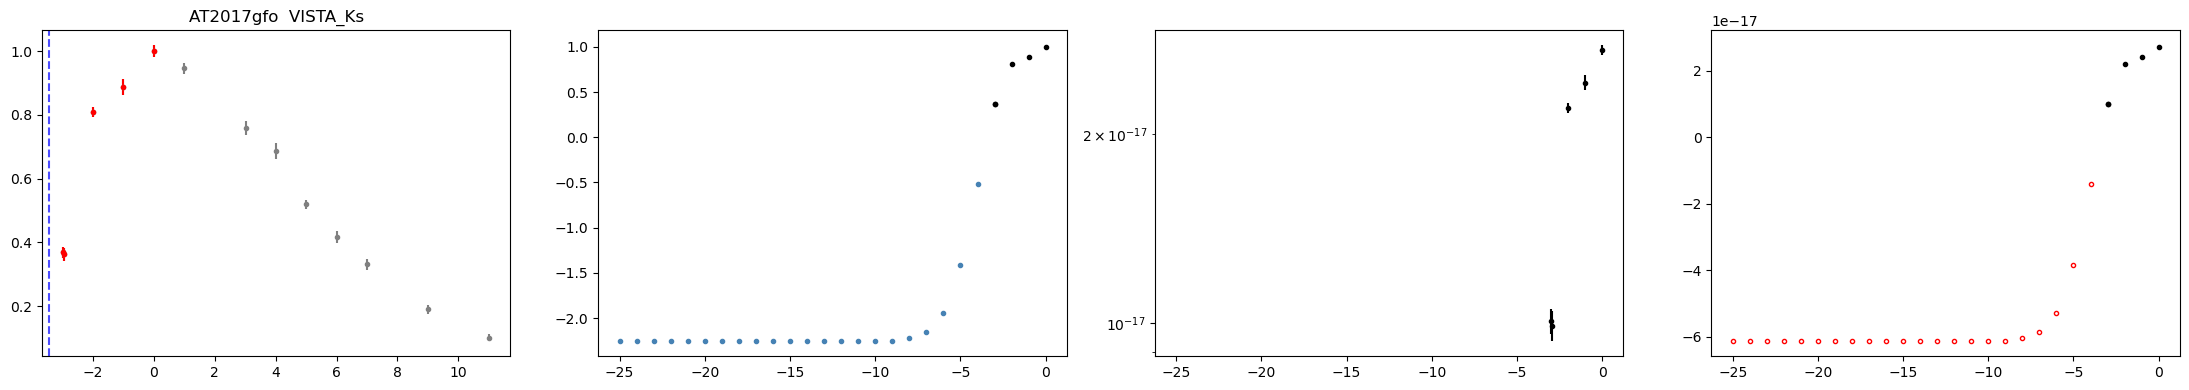

Bazin params [A, t0, t_fall, t_rise]: [23.76975737 -2.8920615  37.17154049  0.6185315 ]


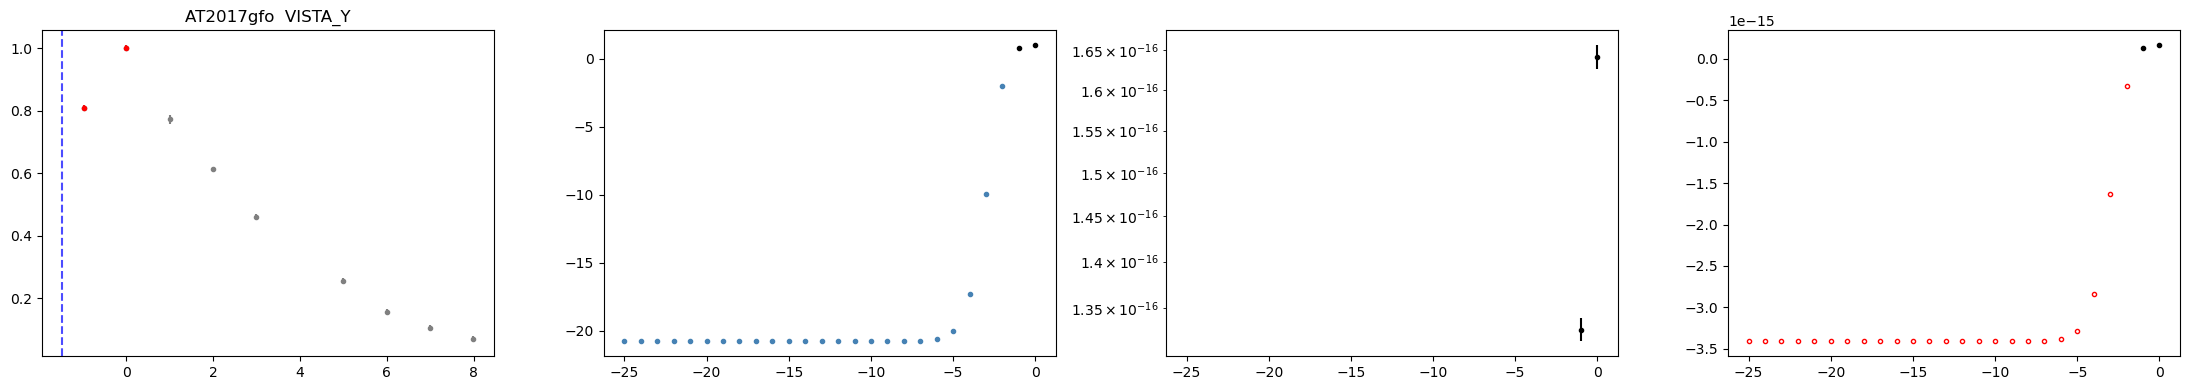

In [12]:
for band in early_bands_keep:
    new_mjd, fit, fit_err, plot_data = SN.fit_early_extend_bazin(band, bazin_config)
    pd_ = plot_data
    fig = plt.figure(figsize=(22, 4))
    plt.subplot(141)
    plt.errorbar(pd_["t"], pd_["fl"], yerr=pd_["flerr"], fmt=".", color="grey")
    plt.errorbar(pd_["t_rise"], pd_["fl_rise"], yerr=pd_["flerr_rise"], fmt=".", color="r")
    plt.axvline(pd_["t_exp"], color="blue", ls="--", alpha=0.7)
    plt.title(f"{snname}  {band}")
    plt.subplot(142)
    plt.errorbar(pd_["t_rise"], pd_["fl_rise"], yerr=pd_["flerr_rise"], fmt=".", color="k")
    fn = bazin_forced_zero_factory(pd_["t_exp"])
    plt.plot(pd_["new_t"], fn(pd_["new_t"], *pd_["bazin_params"]), ".", color="#4682b4")
    plt.subplot(143)
    plt.errorbar(pd_["t_rise"], pd_["orig_flux"][pd_["mask_rising"]], yerr=pd_["orig_flux_err"][pd_["mask_rising"]], fmt=".", color="k")
    plt.errorbar(pd_["new_t"], fit, yerr=fit_err, fmt=".", mec="r", mfc="white", color="r")
    plt.yscale("log")
    plt.subplot(144)
    plt.errorbar(pd_["t_rise"], pd_["orig_flux"][pd_["mask_rising"]], yerr=pd_["orig_flux_err"][pd_["mask_rising"]], fmt=".", color="k")
    plt.errorbar(pd_["new_t"], fit, yerr=fit_err, fmt=".", mec="r", mfc="white", color="r")
    plt.tight_layout()
    plt.show()


## Final single-filter figure (publication)

Run the fitting cell first so `fits_cache` is populated. Adjust `FILTER_FINAL` and the plot kwargs in the next cell.

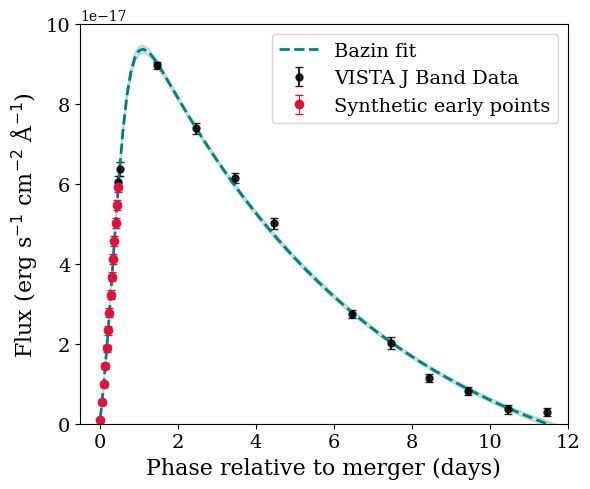

In [13]:
# --- knobs ---
FILTER_FINAL = 'VISTA_J'  # must exist in fits_cache after fit cell
FIGSIZE = (6, 5)
PHASE_REF = explosion_dates[snname][0]
XLIM_PHASE = (-0.5, 12)  # days since explosion
YLIM_FLUX = (0, 1e-16)  # e.g. (0, None) or None for auto
DATA_MARKER = 'o'
DATA_MS = 5
EXTRAP_COLOR = 'crimson'
# ------------

rec = fits_cache.get(FILTER_FINAL)
if rec is None:
    raise KeyError(
        f"{FILTER_FINAL!r} not in fits_cache — check Stage B list and re-run fit cell."
    )

xp = rec['xpeak']
t_ex = np.asarray(rec['t_extrap'])
fn = np.asarray(rec['fitted_norm'])
fe = np.asarray(rec['fitted_err_norm'])
tn = np.asarray(rec['t_newpts'])
pn = np.asarray(rec['newpts_norm'])
pe = np.asarray(rec['newpts_err_norm'])
td = np.asarray(rec['t_data'])
fd = np.asarray(rec['flux_norm']) * xp
fed = np.asarray(rec['fluxerr_norm']) * xp

plt.rcParams['font.family'] = 'serif'
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.errorbar(
    td - PHASE_REF,
    fd,
    yerr=fed,
    fmt=DATA_MARKER,
    ms=DATA_MS,
    color='black',
    label='VISTA J Band Data',
    alpha=0.85,
    capsize=3,
)
ax.plot(t_ex - PHASE_REF, fn * xp, '--', lw=2, color='teal', label='Bazin fit')
ax.fill_between(
    t_ex - PHASE_REF,
    (fn - fe) * xp,
    (fn + fe) * xp,
    #color=color_dict.get(FILTER_FINAL, 'C0'),
    color='teal',
    alpha=0.2,
)
ax.errorbar(
    tn - PHASE_REF,
    pn * xp,
    yerr=pe * xp,
    fmt='o',
    color=EXTRAP_COLOR,
    elinewidth=0.8,
    label='Synthetic early points',
    capsize=3
)
#ax.axvline(0.0, color='0.5', ls=':', lw=1)
ax.set_xlabel('Phase relative to merger (days)', fontsize=16)
ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)

#ax.set_title(f'{snname} — {FILTER_FINAL}')
ax.set_xlim(*XLIM_PHASE)
if YLIM_FLUX is not None:
    ax.set_ylim(*YLIM_FLUX)#
ax.legend(loc='best', fontsize=14)
plt.tight_layout()
#plt.savefig('/Users/ravkaur/Desktop/research/kilonova-SED/kn-sed-pipeline/Outputs/AT2017gfo/plots-for-flash/VISTA_J_Bazin_fit.png', dpi=500, bbox_inches='tight')
plt.show()
